# **Machine Learning Bonus: Tiki Best-Seller Classifier**

## **1. Library Declarations and Constants**

In [2]:
from pathlib import Path
import json
import pickle

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TARGET_COL = "Is_Best_Seller"

## **2. Load and Join Data**

- Đọc 3 bảng từ `data/processed`: `fact_tiki_listings`, `dim_product`, `dim_category`.
- Join theo khóa `product_id`, `category_id` để gom feature về một bảng huấn luyện.

In [3]:
def load_and_join_data(data_dir: Path) -> pd.DataFrame:
    """Load and join fact + dimensions for Tiki products."""
    fact_path = data_dir / "fact_tiki_listings.csv"
    product_path = data_dir / "dim_product.csv"
    category_path = data_dir / "dim_category.csv"

    df_fact = pd.read_csv(fact_path, dtype={"product_id": str})
    df_product = pd.read_csv(product_path, dtype={"product_id": str, "category_id": str})
    df_category = pd.read_csv(category_path, dtype={"category_id": str})

    joined = df_fact.merge(
        df_product[["product_id", "brand", "category_id"]],
        on="product_id",
        how="left",
    )
    joined = joined.merge(
        df_category[["category_id", "category"]],
        on="category_id",
        how="left",
    )
    return joined

root_dir = Path.cwd().parents[0]
data_dir = root_dir / "data" / "processed"
df_joined = load_and_join_data(data_dir)
df_joined.head()

,product_id,price,original_price,discount_rate,rating_average,review_count,quantity_sold,Discount_Segment,Is_Best_Seller,brand,category_id,category
0,277305929,320000.0,320000,0,0.0,0,0,0%,0,Arctic Hunter,CAT_0001,Thời Trang Nữ
1,275767409,610000.0,610000,0,0.0,0,0,0%,0,Ingco,CAT_0002,Unknown
2,12276970,509000.0,509000,0,4.8,15,51,0%,0,Dareu,CAT_0003,Thiết Bị Số - Phụ Kiện Số
3,99324795,45000.0,50000,10,4.5,4,49,< 20%,0,Sk Food,CAT_0004,Các Loại Rong Biển Ăn Liền
4,272413292,69000.0,69000,0,5.0,2,21,0%,0,Gor,CAT_0003,Thiết Bị Số - Phụ Kiện Số


### Insight
- Bảng sau join thường có thêm `brand` và `category`, giúp mô hình có thêm tín hiệu ngữ nghĩa sản phẩm.
- Nếu xuất hiện nhiều giá trị null ở `brand/category`, cần kiểm tra độ đầy đủ của khóa join.

## **Tiền xử lý và Feature Engineering**


- Ép kiểu số cho các cột giá, giảm giá, rating và target.
- Điền thiếu cho `brand/category` bằng `Unknown`.
- Tạo feature `Price_Gap = original_price - price` và chặn giá trị âm.
- Loại dòng thiếu dữ liệu quan trọng và chuẩn hóa target về kiểu int.


- Mô hình cây tăng cường hoạt động tốt khi feature số rõ ràng, không lẫn ký tự.
- Feature engineering giúp đưa tri thức nghiệp vụ vào mô hình (khoảng chênh giá phản ánh mức khuyến mãi tuyệt đối).
- Làm sạch dữ liệu trước huấn luyện giúp tránh nhiễu và lỗi runtime.

In [3]:
def preprocess_and_engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Clean raw columns and create engineered features."""
    out = df.copy()

    numeric_cols = [
        "price",
        "original_price",
        "discount_rate",
        "rating_average",
        TARGET_COL,
    ]
    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["brand"] = out["brand"].fillna("Unknown").astype(str)
    out["category"] = out["category"].fillna("Unknown").astype(str)

    out["Price_Gap"] = out["original_price"] - out["price"]
    out["Price_Gap"] = out["Price_Gap"].clip(lower=0)

    out = out.dropna(subset=numeric_cols)
    out[TARGET_COL] = out[TARGET_COL].astype(int)

    return out

df_model = preprocess_and_engineer_features(df_joined)
df_model[["price", "original_price", "Price_Gap", "discount_rate", "rating_average", TARGET_COL]].describe().T

,count,mean,std,min,25%,50%,75%,max
price,10000.0,459890.79980,9.031707e+05,1000.0,89000.0,171000.0,385000.0,6160790.0
original_price,10000.0,537016.06420,1.055923e+06,1000.0,99000.0,195000.0,446250.0,6990000.0
Price_Gap,10000.0,77412.75720,2.708927e+05,0.0,0.0,0.0,33000.0,3693000.0
discount_rate,10000.0,10.02250,1.529746e+01,0.0,0.0,0.0,20.0,77.0
rating_average,10000.0,2.90184,2.320689e+00,0.0,0.0,4.5,5.0,5.0
Is_Best_Seller,10000.0,0.24340,4.291560e-01,0.0,0.0,0.0,0.0,1.0


### Insight
- `Price_Gap` lớn cho thấy sản phẩm được giảm nhiều theo giá trị tuyệt đối, thường là tín hiệu liên quan đến hành vi mua.
- Số dòng giảm sau `dropna` phản ánh mức thiếu dữ liệu ban đầu; nếu giảm quá mạnh, cần cân nhắc chiến lược imputing thay vì loại bỏ.

## **3. Train/Test Split and Frequency Encoding**


- Chia tập train/test theo tỷ lệ 80/20 và `stratify` theo nhãn đích.
- Tính tần suất xuất hiện (`value_counts(normalize=True)`) của `brand/category` trên train.
- Ánh xạ tần suất này sang train và test tạo `brand_freq`, `category_freq`.

- Stratified split giữ phân phối lớp gần giống giữa train và test.
- Frequency encoding là cách chuyển biến phân loại sang số nhẹ và hiệu quả cho tree model.
- Tính encoder từ train rồi áp sang test giúp tránh data leakage.

In [4]:
def add_frequency_encoding(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, dict[str, float]]]:
    """Add frequency-encoded categorical features using train-only statistics."""
    train_out = train_df.copy()
    test_out = test_df.copy()

    encoders: dict[str, dict[str, float]] = {}
    for col in ["brand", "category"]:
        freq = train_out[col].value_counts(normalize=True).to_dict()
        encoders[col] = freq

        train_out[f"{col}_freq"] = train_out[col].map(freq).fillna(0.0)
        test_out[f"{col}_freq"] = test_out[col].map(freq).fillna(0.0)

    return train_out, test_out, encoders

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_model[TARGET_COL],
)

train_df, test_df, encoders = add_frequency_encoding(train_df, test_df)
train_df[["brand", "brand_freq", "category", "category_freq"]].head()

,brand,brand_freq,category,category_freq
95,Nillkin,0.002250,Thiết Bị Số - Phụ Kiện Số,0.098000
1035,Toshiba,0.004125,Điện Gia Dụng,0.097625
8174,Trung Nguyên Legend,0.004500,Bách Hóa Online,0.108125
5606,Minh Hà Foods,0.000250,Bách Hóa Online,0.108125
7545,Sohogo,0.000375,Nhà Cửa - Đời Sống,0.097375


### Insight
- Các `*_freq` nằm trong [0, 1], phản ánh mức phổ biến của nhãn phân loại.
- Những category/brand hiếm thường có tần suất nhỏ, có thể tạo phân tách tốt trong cây quyết định.

## **4. Build Feature Matrix and Train XGBoost**

- Chọn 7 feature cuối cùng cho mô hình.
- Tính `scale_pos_weight = negative / positive` để xử lý mất cân bằng lớp.
- Huấn luyện `XGBClassifier` với objective nhị phân và metric AUC.

- XGBoost là boosting trên cây, mạnh cho dữ liệu bảng (tabular).
- Với class imbalance, tăng trọng số lớp dương giúp mô hình chú ý hơn tới lớp hiếm.
- AUC đo năng lực phân biệt theo mọi ngưỡng xác suất, phù hợp hơn accuracy khi lệch lớp.

In [5]:
def build_feature_matrix(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Return model-ready X and y."""
    feature_cols = [
        "price",
        "original_price",
        "discount_rate",
        "rating_average",
        "Price_Gap",
        "brand_freq",
        "category_freq",
    ]
    X = df[feature_cols].copy()
    y = df[TARGET_COL].copy()
    return X, y

def train_xgboost_classifier(X_train: pd.DataFrame, y_train: pd.Series) -> XGBClassifier:
    """Train XGBoost with imbalance-aware weighting."""
    positive = int((y_train == 1).sum())
    negative = int((y_train == 0).sum())
    scale_pos_weight = (negative / positive) if positive > 0 else 1.0

    model = XGBClassifier(
        n_estimators=350,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.2,
        reg_lambda=1.0,
        min_child_weight=3,
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    return model

X_train, y_train = build_feature_matrix(train_df)
X_test, y_test = build_feature_matrix(test_df)
model = train_xgboost_classifier(X_train, y_train)
model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### Insight
- Nếu `scale_pos_weight` > 1 nghĩa là lớp dương hiếm hơn lớp âm; đây là trạng thái thường gặp với nhãn best-seller.
- Mô hình huấn luyện xong là nền tảng để đánh giá chất lượng và giải thích quyết định dự báo.

## **5. Model Evaluation**

- Tính xác suất dự báo và nhãn dự báo theo ngưỡng 0.5.
- Tính Confusion Matrix, ROC-AUC, ROC Curve, và Classification Report.

- Confusion Matrix cho biết số lượng TP, TN, FP, FN.
- ROC-AUC càng gần 1 càng tốt, phản ánh khả năng xếp hạng mẫu dương cao hơn mẫu âm.
- Precision/Recall/F1 cho góc nhìn sâu hơn accuracy, đặc biệt khi lớp lệch.

In [6]:
def evaluate_model(model: XGBClassifier, X_test: pd.DataFrame, y_test: pd.Series) -> dict[str, object]:
    """Compute confusion matrix, ROC-AUC, and related diagnostics."""
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    return {
        "confusion_matrix": cm,
        "roc_auc": float(auc),
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "classification_report": report,
        "y_proba": y_proba,
    }

eval_payload = evaluate_model(model, X_test, y_test)
print("ROC-AUC:", round(eval_payload["roc_auc"], 4))
print("Confusion matrix:\n", eval_payload["confusion_matrix"])

ROC-AUC: 0.9156
Confusion matrix:
 [[1256  257]
 [  86  401]]


### Insight
- ROC-AUC là thước đo tổng quan chất lượng phân loại; giá trị cao cho thấy khả năng tách lớp tốt.
- Từ confusion matrix có thể xác định mô hình đang thiên về bỏ sót best-seller (FN cao) hay dự báo nhầm quá nhiều (FP cao).
- Nếu mục tiêu kinh doanh ưu tiên không bỏ sót best-seller, có thể giảm ngưỡng từ 0.5 để tăng recall lớp 1.

## **6. Result Visualization**

- Gồm 4 góc nhìn: Confusion Matrix, ROC Curve, phân phối xác suất dự báo, và Top Feature Importance.

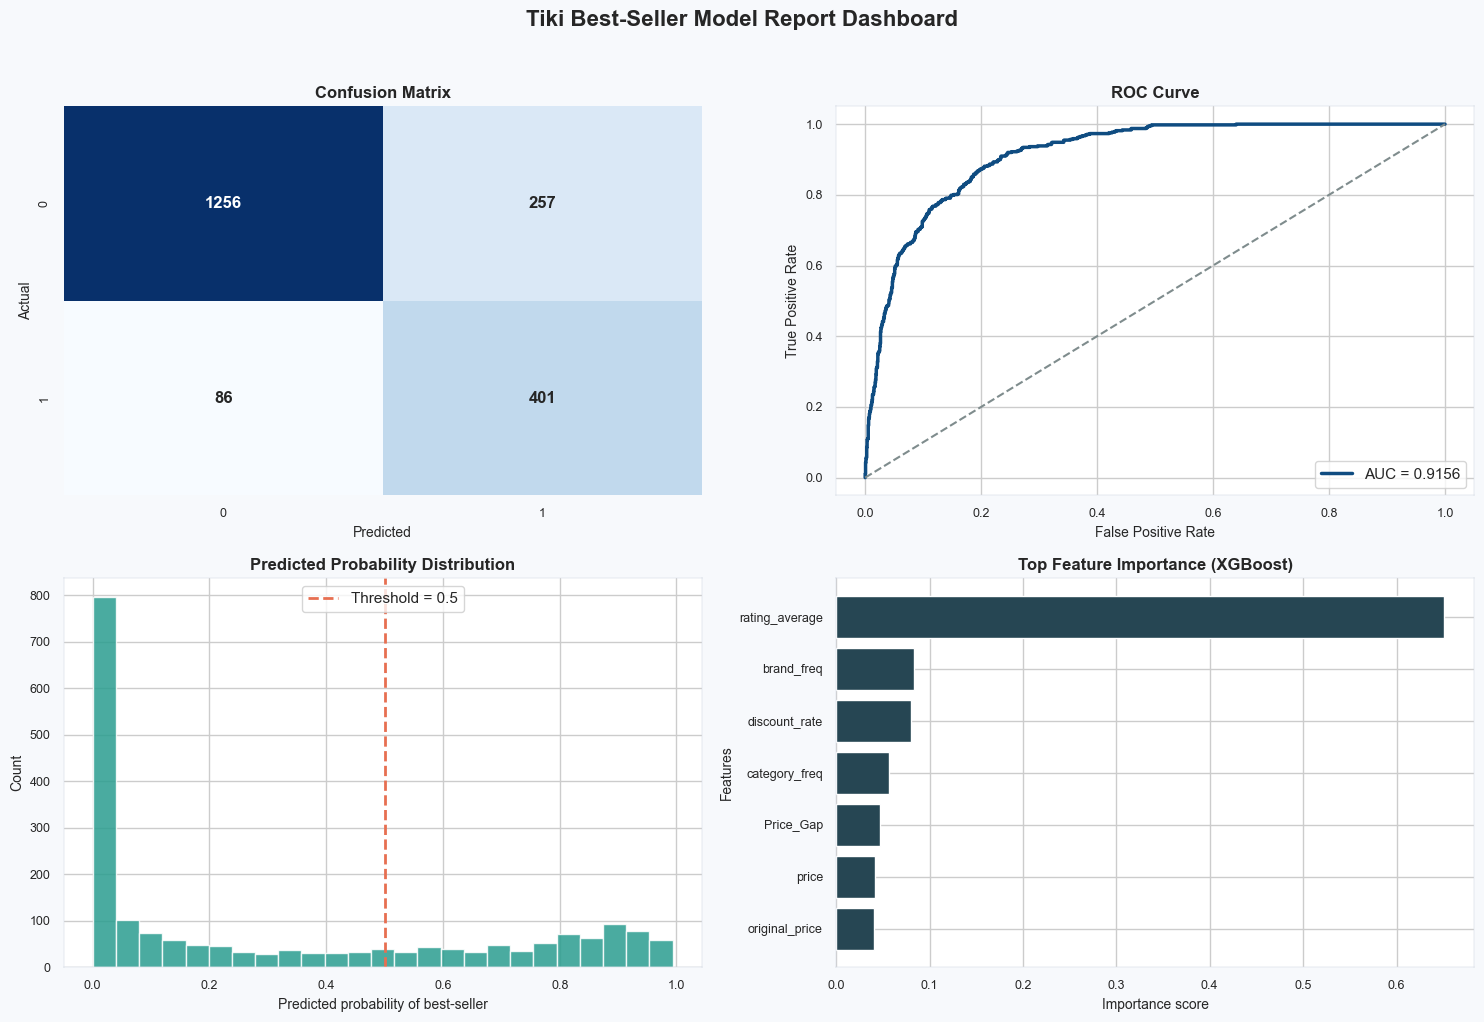

In [7]:
# Report-ready visualization block
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "#F7F9FC",
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": "#D6DCE5",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

cm = eval_payload["confusion_matrix"]
fpr = eval_payload["fpr"]
tpr = eval_payload["tpr"]
y_proba = eval_payload["y_proba"]
roc_auc = eval_payload["roc_auc"]

importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Tiki Best-Seller Model Report Dashboard", fontsize=16, fontweight="bold", y=1.02)

# 1) Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    annot_kws={"fontsize": 12, "fontweight": "bold"},
)
axes[0, 0].set_title("Confusion Matrix")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")

# 2) ROC curve
axes[0, 1].plot(fpr, tpr, color="#0F4C81", linewidth=2.5, label=f"AUC = {roc_auc:.4f}")
axes[0, 1].plot([0, 1], [0, 1], linestyle="--", color="#7F8C8D", linewidth=1.5)
axes[0, 1].set_title("ROC Curve")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].legend(loc="lower right", frameon=True)

# 3) Predicted probability distribution
axes[1, 0].hist(y_proba, bins=25, color="#2A9D8F", alpha=0.85, edgecolor="white")
axes[1, 0].axvline(0.5, color="#E76F51", linestyle="--", linewidth=2, label="Threshold = 0.5")
axes[1, 0].set_title("Predicted Probability Distribution")
axes[1, 0].set_xlabel("Predicted probability of best-seller")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend(loc="upper center")

# 4) Top feature importance
top_imp = importance.head(7).sort_values(ascending=True)
axes[1, 1].barh(top_imp.index, top_imp.values, color="#264653")
axes[1, 1].set_title("Top Feature Importance (XGBoost)")
axes[1, 1].set_xlabel("Importance score")
axes[1, 1].set_ylabel("Features")

for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_alpha(0.35)

plt.tight_layout()
plt.show()

### Insight cho báo cáo
- Dashboard 2x2 giúp người xem nắm nhanh cả hiệu năng tổng thể (ROC-AUC), lỗi phân loại (Confusion Matrix) và hành vi dự báo (phân phối xác suất).
- Top Feature Importance cho thấy biến nào chi phối quyết định của mô hình, giúp phần thảo luận nghiệp vụ thuyết phục hơn.
- Có thể chụp trực tiếp hình này để đưa vào slide kết quả mô hình.

## **7. SHAP Explainability**

- Tạo `TreeExplainer` cho mô hình XGBoost.
- Tính SHAP values trên tập train để đo đóng góp của từng feature vào dự báo.

- SHAP dựa trên Shapley value trong game theory: phân phối công bằng đóng góp của từng biến vào output.
- Với tree-based model, Tree SHAP cho tính toán nhanh và ổn định.

SHAP shape: (8000, 7)


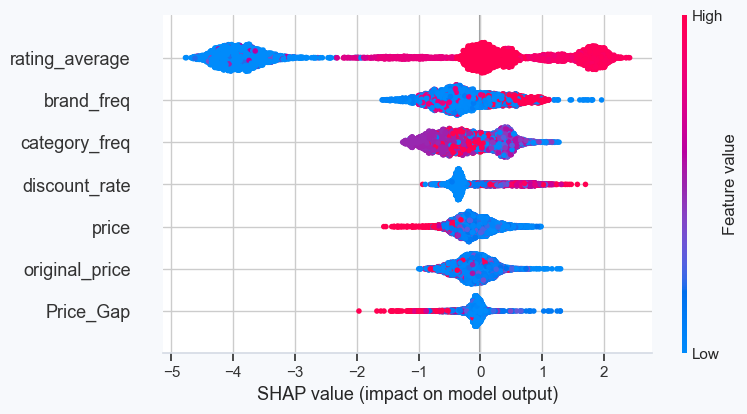

In [8]:
def compute_shap_values(model: XGBClassifier, X_train: pd.DataFrame) -> np.ndarray:
    """Compute SHAP values for tree model."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    return np.asarray(shap_values)

shap_values = compute_shap_values(model, X_train)
print("SHAP shape:", shap_values.shape)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_train, show=False)
plt.tight_layout()
plt.show()

### Insight
- Biểu đồ SHAP summary cho biết feature nào ảnh hưởng mạnh nhất đến quyết định của mô hình.
- Dấu và độ lớn SHAP giúp hiểu chiều tác động: giá trị feature cao có đẩy xác suất best-seller lên hay xuống.
- Đây là bước quan trọng để giải thích mô hình với stakeholder không chuyên kỹ thuật.

## **8. Save Artifacts and Run Full Pipeline**

- Lưu model, confusion matrix, shap values, metrics, encoder.
- Lưu thêm hình ROC curve và SHAP summary.
- Gom toàn bộ bước thành hàm `run_pipeline()` để chạy một lệnh là hoàn tất.

- Tách artifacts phục vụ deployment, monitoring và tái sử dụng.
- Pipeline hóa giúp chuẩn hóa quy trình thí nghiệm và giảm sai sót thao tác thủ công.

In [9]:
def save_roc_auc_plot(fpr: np.ndarray, tpr: np.ndarray, roc_auc: float, out_path: Path) -> None:
    """Save ROC curve figure."""
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC-AUC Curve - Tiki Best-Seller Classifier")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

def save_shap_summary_plot(shap_values: np.ndarray, X_train: pd.DataFrame, out_path: Path) -> None:
    """Save SHAP summary plot to image."""
    plt.figure(figsize=(9, 6))
    shap.summary_plot(shap_values, X_train, show=False)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()

def save_artifacts(
    models_dir: Path,
    model: XGBClassifier,
    conf_matrix: np.ndarray,
    shap_values: np.ndarray,
    metrics_payload: dict[str, object],
    encoders: dict[str, dict[str, float]],
) -> None:
    """Persist required and supporting artifacts."""
    models_dir.mkdir(parents=True, exist_ok=True)

    model_path = models_dir / "xgboost_tiki.pkl"
    cm_path = models_dir / "confusion_matrix.npy"
    shap_path = models_dir / "shap_values.pkl"
    metrics_path = models_dir / "metrics.json"
    encoders_path = models_dir / "encoders.pkl"

    joblib.dump(model, model_path)
    np.save(cm_path, conf_matrix)
    with open(shap_path, "wb") as f:
        pickle.dump(shap_values, f)

    serializable_metrics = {
        "roc_auc": float(metrics_payload["roc_auc"]),
        "classification_report": metrics_payload["classification_report"],
    }
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(serializable_metrics, f, ensure_ascii=False, indent=2)

    joblib.dump(encoders, encoders_path)

def run_pipeline(data_dir: Path | None = None, models_dir: Path | None = None) -> dict[str, object]:
    """Execute the full training + explainability pipeline."""
    root_dir = Path.cwd().parents[0]
    data_dir = data_dir or (root_dir / "data" / "processed")
    models_dir = models_dir or (root_dir / "models")

    df_joined = load_and_join_data(data_dir)
    df_model = preprocess_and_engineer_features(df_joined)

    train_df, test_df = train_test_split(
        df_model,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=df_model[TARGET_COL],
    )

    train_df, test_df, encoders = add_frequency_encoding(train_df, test_df)

    X_train, y_train = build_feature_matrix(train_df)
    X_test, y_test = build_feature_matrix(test_df)

    model = train_xgboost_classifier(X_train, y_train)
    eval_payload = evaluate_model(model, X_test, y_test)
    shap_values = compute_shap_values(model, X_train)

    save_artifacts(
        models_dir=models_dir,
        model=model,
        conf_matrix=eval_payload["confusion_matrix"],
        shap_values=shap_values,
        metrics_payload=eval_payload,
        encoders=encoders,
    )

    save_roc_auc_plot(
        eval_payload["fpr"],
        eval_payload["tpr"],
        float(eval_payload["roc_auc"]),
        models_dir / "roc_auc_curve.png",
    )
    save_shap_summary_plot(shap_values, X_train, models_dir / "shap_summary.png")

    return {
        "rows_total": int(len(df_model)),
        "rows_train": int(len(train_df)),
        "rows_test": int(len(test_df)),
        "positive_rate": float(df_model[TARGET_COL].mean()),
        "roc_auc": float(eval_payload["roc_auc"]),
#         "models_dir": str(models_dir),
    }

summary = run_pipeline()
print(json.dumps(summary, indent=2))

{
  "rows_total": 10000,
  "rows_train": 8000,
  "rows_test": 2000,
  "positive_rate": 0.2434,
  "roc_auc": 0.9155701918078909
}


## **8. LLM-Powered Explanation (Bonus: AI Layer)**

Sau khi XGBoost dự đoán xác suất Best Seller, ta tích hợp thêm một lớp **LLM (Large Language Model)** để:
- Giải thích kết quả dự đoán bằng ngôn ngữ tự nhiên
- Phân tích yếu tố chính, rủi ro, và đề xuất hành động
- Hỗ trợ đa provider: OpenAI, Google Gemini, Anthropic Claude, xAI Grok, Groq

Module được implement tại src/ml/llm_explainer.py.

### **8.1 Architecture**

Quy trình:

1. XGBoost predict_proba(X) 
2. build_prompt(features, proba, lang='en'/'vi')
3. explain_stream(provider='groq', ...)  
4. st.write_stream(generator)          



| Provider | Package | Key env var |
|---|---|---|
| OpenAI (GPT-4o mini) | openai | OPENAI_API_KEY |
| Google Gemini 1.5 Flash | google-generativeai | GEMINI_API_KEY |
| Anthropic Claude Haiku | anthropic | ANTHROPIC_API_KEY |
| xAI Grok | openai | GROK_API_KEY |
| Groq (Llama 3.3 70B) | openai | GROQ_API_KEY |

In [12]:
import sys
from pathlib import Path

# Add src/ml to path so we can import llm_explainer
SRC_ML = Path("../src/ml").resolve()
if str(SRC_ML) not in sys.path:
    sys.path.insert(0, str(SRC_ML))

from llm_explainer import (
    build_prompt,
    detect_available_providers,
    explain,
    explain_stream,
    PROVIDER_LABELS,
)

print("llm_explainer loaded successfully")
print("Available providers:", detect_available_providers())

llm_explainer loaded successfully
Available providers: []


### **8.2 Prompt Construction**

Tiến hành build_prompt() nhận feature dict,xác suất và tạo prompt chuẩn hoá.
Hỗ trợ tiếng Anh và tiếng Việt.

In [14]:
# Example feature vector (same structure as what the dashboard sends)
sample_features = {
    "price":          450_000,
    "original_price": 600_000,
    "discount_rate":  25.0,
    "rating_average": 4.5,
    "Price_Gap":      150_000,
    "brand_freq":     0.042,    # 4.2% of Tiki listings
    "category_freq":  0.085,    # 8.5% of Tiki listings
}
sample_proba = 0.72  # XGBoost predicted 72% probability

# Print the English prompt
print("English Prompt")
print(build_prompt(sample_features, sample_proba, lang="en"))
print()
print("Vietnamese Prompt")
print(build_prompt(sample_features, sample_proba, lang="vi"))

English Prompt
You are an e-commerce analyst specialized in Tiki, Vietnam's leading marketplace.

An XGBoost classifier trained on 10,000 real Tiki listings predicts this product has a 72.0% probability of becoming a Best Seller.

Product metrics:
- Selling price: 450,000 VND
- Original price: 600,000 VND
- Discount rate: 25.0%
- Price markdown (gap): 150,000 VND
- Rating average: 4.5 / 5.0
- Category popularity: 8.5% of all Tiki listings
- Brand popularity: 4.2% of all Tiki listings

Model verdict: BEST SELLER (classification threshold = 50%)

Respond with exactly 3 bullet points:
1. The primary driver(s) behind this prediction based on the numbers
2. The biggest risk factor or weakness in these metrics
3. One concrete, actionable step to increase Best Seller probability

Keep each bullet under 60 words. Be data-specific, avoid generic advice.

Vietnamese Prompt
Bạn là chuyên gia phân tích thương mại điện tử, chuyên về Tiki — sàn TMĐT hàng đầu Việt Nam.

Mô hình XGBoost được huấn luyệ

### **8.3 Calling the LLM**

Cần API key được set trong .env tại project root.


In [15]:
from dotenv import load_dotenv
load_dotenv("../.env")

available = detect_available_providers()
if not available:
    print("No API keys configured in .env — skipping live call.")
    print("Set one of: GROQ_API_KEY, OPENAI_API_KEY, GEMINI_API_KEY, ANTHROPIC_API_KEY, GROK_API_KEY")
else:
    provider = available[0]
    print(f"Using provider: {PROVIDER_LABELS[provider]}")
    print()

    # Non-streaming call
    result = explain(sample_features, sample_proba, provider=provider, lang="en")
    print(result)

Using provider: Groq (Llama 3.3 70B)

* High rating average (4.5/5) and significant discount rate (25%) drive the prediction.
* Low brand popularity (4.2%) is the biggest risk factor.
* Increase brand popularity to 6% to leverage category popularity (8.5%) and boost Best Seller probability.


In [16]:
# Streaming demo (prints chunks as they arrive — same as Streamlit st.write_stream)
if available:
    print(f"[Streaming — {PROVIDER_LABELS[provider]}]\n")
    for chunk in explain_stream(sample_features, sample_proba, provider=provider, lang="vi"):
        print(chunk, end="", flush=True)
    print()

[Streaming — Groq (Llama 3.3 70B)]

* Yếu tố chính: Tỷ lệ giảm giá 25% và điểm đánh giá 4.5/5.
* Yếu tố rủi ro: Mức độ phổ biến thương hiệu thấp (4.2%).
* Hành động: Tăng mức độ phổ biến thương hiệu qua quảng cáo.


### **Final Insights**
- Pipeline đã hoàn chỉnh từ dữ liệu thô đã xử lý đến mô hình, đánh giá, giải thích và lưu artifacts.
- Kết quả `summary` cung cấp nhanh quy mô dữ liệu, tỷ lệ lớp dương và chất lượng AUC cuối cùng.
- Tập tin sinh ra trong thư mục `models/` hỗ trợ trực tiếp cho báo cáo, tái chạy và triển khai tiếp theo.